-----
# AM10 - Computing for Science and Engineering - Module 3

## Section 11
-----

### Learning objectives:

- Applications: Rejection method for creating random number with arbitrary distributions

- Applications: Monte Carlo integration

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Generating random numbers with arbitrary distributions

The modulo algorithm you have seen in the lecture generates random numbers that are distributed uniformly in the range 0 to 1. What if you want random numbers with a different distribution? 

You saw an example of transforming a uniform linear distribution to a uniform radian distribution in the lecture. Similarly, there are ways to convert a uniform distribution to a normal distribution (see Section 11.3 in the Lecture notes). 

One can derive such transformations by using the probability density function of the required distribution. However, doing so is often difficult and in many cases not analytically possible. 

In the exercise below we will see how we can use the simple *rejection* algorithm to generate random numbers of any arbitrary distribution. This is, as you will see, a simple yet powerful method and is used extensively in various Monte Carlo techniques. 

Remember our second implementation of the Monte Carlo integration in the lab (the function `mc_int2`)? We picked uniformly distributed random numbers (say $u_1$) in a given range ($a$, $b$), then evaluated the function $f(u_1)$. We picked another uniform random number, say $u_2$ in the range ($0$, $d$), where $d$ should be the maximum of the function $f(x)$ in the range ($a$, $b$). Then, we checked whether $u_2$ lied under $f(u_1)$ and rejected those that did not. Now, if we keep rejecting the random numbers $u_1$ that do not satisfy our criteria and keep all those that do, we will end up with only the random numbers that are distributed according to the function $f(x)$.

Let's try this out.

### Exercise 1

Using the code from Lab 11 for the function `mc_int2` create a function (call it `mc_reject`) to generate random numbers with any given distribution. The inputs to this new function should be
1. A function function representing the mathematical distribution, call this input `func`
2. The number of random numbers to be generated, call this input `numr`
3. The minimum of the range, `a`
4. The maximum of the range, `b`
5. The maximum of the distribution function, `d`

The output of this function should be an array (or list) of the generated random numbers.

The code for `mcint_1d` is copied below:

In [ ]:
def mcint2(func, nump, a, b):
    '''
        Input:
            func: Python function representing the mathematical function to be integrated
            nump: number of random samples to draw for Monte Carlo
            a: minimum of range
            b: maximum of range
        Output:
            intfin: value of the integral
    '''
    intsum = 0
    d = np.maximum(func(a), func(b))
    for i in range(nump):
        x = a + np.random.rand() * (b - a)
        y = np.random.rand() * d
        if (y < func(x)):
            intsum = intsum + 1.0
    intfin = (b - a) * d * intsum / nump
    return intfin

In [3]:
def mc_reject(func, numr, a, b, d):
    '''
        Input:
            func: Python function representing the distribution function 
            numr: number of random samples to draw for Monte Carlo
            a: minimum of range
            b: maximum of range
            d: maximum of distribution
        Output:
            xr: list of random number generated with required distribution
    '''
    xr = []
    nr = 0
    while nr < numr:
        x = a + np.random.rand() * (b - a)
        y = np.random.rand() * d
        if (y < func(x)):
            xr.append(x)
            nr = nr + 1 
    return xr 

### Exercise 2 

Test the above function `mc_reject` by generating 1000 random numbers with a distribution given by the function below.
$$ f(x) = \frac{1}{x^2+1}$$

Use a range of ($-5$, $5$) for $x$. Plot a histogram of the generated random numbers to visualize their distribution.

In [5]:
# define the python function for the distribution function
def fofx(x):
    y = 1 / (x**2 + 1)
    return y

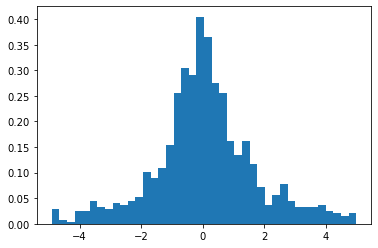

In [17]:
# define constants and inputs
numr = 1000
a = -5
b = 5 
d = 1 
xr = mc_reject(fofx,numr,a,b,d)
# plot histogram
plt.hist(xr, bins =40, density = True)
plt.show()

## Comparing multivariable Monte Carlo integration with the Rectangular method

### Exercise 3
Let's extend the `mcint_2d` function we wrote in lab to three dimensions and call it `mcint_3d`.

In [27]:
def mcint_3d(func, nump, ax, bx, ay, by, az, bz):
    '''
        Input:
            func: Python function representing the mathematical function to be integrated
            nump: number of random samples to draw for Monte Carlo
            ax: minimum of range along x
            bx: maximum of range along x
            ay: minimum of range along y
            by: maximum of range along y            
        Output:
            intfin: value of the integral
    '''
    intsum = 0
    for i in range(nump):
        x = ax + np.random.rand() * (bx - ax)
        y = ay + np.random.rand() * (by - ay)
        z = az + np.random.rand() * (bz - az)
        intsum = intsum + func(x,y,z)
    intfin = (bx - ax) * (by - ay) * (bz - az) * intsum / nump
    
    return intfin 

Now Let's test this on a simple function of three variable.
$$f_{3d}(x, y, z) = \sin{x}\sin{y}\sin{z}$$

Integrate the function above in the range $0$ to $\pi$ for all three variables. The theoretical answer obviously is 8.

In [19]:
def f3d(x, y, z):
    return np.sin(x) * np.sin(y) * np.sin(z)

In [44]:
ax = 0
bx = np.pi
ay = 0
by = np.pi
az = 0
bz = np.pi
nump = 1000
int4 = mcint_3d(f3d, nump, ax, bx, ay, by, az, bz) 
print(int4)

7.92789217265947


Now, let's write a simple function that should be very similar to `mcint_3d`, but using the Rectangular method. We will call this `rectint_3d`. We are trying to implement the same expression as below
\begin{equation}
\int_a^bf(x)dx \approx \frac{b-a}{N}\sum_{i=0}^{N-1}f(x_i).
\end{equation}
but this time, we will be using a regular grid of points for $x$, $y$, and $z$. Finally, test the function for the same function using the same number of points as the Monte Carlo (1000), i.e., 10 points for each dimension.

In [38]:
def rectint_3d(func, numx, numy, numz, ax, bx, ay, by, az, bz):
    intsum = 0
    x = np.linspace(ax,bx,numx)
    y = np.linspace(ay,by,numy)
    z = np.linspace(az,bz,numz)
    for i in range(numx):
        for j in range (numy):
            for k in range (numz):
                intsum = intsum + func(x[i],y[j],z[k])
    intfin = (bx - ax) * (by - ay) * (bz - az) * intsum / ((numx-1)*(numy-1)*(numz-1))
                
    return intfin

In [45]:
numx = 10
numy = 10
numz = 10
int5 = rectint_3d(f3d, numx, numy, numz, ax, bx, ay, by, az, bz)
print(int5)

7.758285845117573


We can also time the computation of these two functions and compare as show below.

In [46]:
%timeit mcint_3d(f3d, nump, ax, bx, ay, by, az, bz) 

5.38 ms ± 390 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [47]:
%timeit rectint_3d(f3d, numx, numy, numz, ax, bx, ay, by, az, bz)

8.12 ms ± 846 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## Applications of Random Numbers: Coin Tossing Game

### Exercise 4
Let's play a coin tossing game. We will toss a coin (or rather simulate a coin toss) and record the face. The goal is to see how many tosses it takes to get a given sequence of faces.
Assume that you are looking for the sequence heads-tails-tails.

Let's define heads as 0 and tails as 1 for simplicity.

In [55]:
# define target sequence
targetseq = '011' # heads tails tails 


# initialize empty sequence
seq = [0, 0, 0]

# convert last three entries of sequence to string
seqcheck = str(seq[-3])+str(seq[-2])+str(seq[-1])

avgtosses = 0
numgames = 10000
for i in range(numgames):
# run while loop
    while seqcheck != targetseq:
        # toss a coin
        toss = np.random.randint(0,2) # 2 is not included 
        # append result of coin toss to sequence
        seq.append(toss)
        # update string with the last three entries of sequence
        seqcheck = str(seq[-3])+str(seq[-2])+str(seq[-1])
    avgtosses = avgtosses + len(seq)
avgtosses = avgtosses / numgames
# display results
print("Average number of tosses to get to the desired sequence =", len(seq))
print('')
print(seq)


Average number of tosses to get to the desired sequence = 10

[0, 0, 0, 1, 0, 1, 0, 0, 1, 1]
